# Autoencoder — Unsupervised Anomaly Detection

A second, distinct task alongside the supervised binary/multi-class classification: an autoencoder is trained **only on Normal traffic**, learning to reconstruct normal patterns. At test time, traffic that reconstructs poorly (high reconstruction error) is flagged as an attack — a genuinely different learning approach (unsupervised, reconstruction-based) from the supervised DNN classifiers.

Two design factors are explored in isolation (bottleneck size, anomaly threshold), then combined into a final model — the same one-factor-at-a-time methodology used for the supervised classification task.

Import libraries

In [1]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs("../models", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
os.makedirs("../results", exist_ok=True)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


Check GPU availability

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU detected:", gpus)
else:
    print("No GPU detected. Training will use the CPU.")


No GPU detected. Training will use the CPU.


Load preprocessed binary data (reuses the same features as the binary DNN — only Normal-labeled rows are used for training)

In [3]:
X_train_final = np.load("../results/X_train_binary.npy").astype("float32")
X_val = np.load("../results/X_val_binary.npy").astype("float32")
X_test = np.load("../results/X_test_binary.npy").astype("float32")

y_train_final = np.load("../results/y_train_binary.npy").astype("int32")
y_val = np.load("../results/y_val_binary.npy").astype("int32")
y_test = np.load("../results/y_test_binary.npy").astype("int32")

print("Training set  :", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Testing set   :", X_test.shape)


Training set  : (65865, 190)
Validation set: (16467, 190)
Testing set   : (175341, 190)


## Isolate Normal-only training data

The autoencoder must only ever see Normal traffic during training — if it learns to reconstruct attacks too, it loses its ability to flag them as anomalous.

In [4]:
X_train_normal = X_train_final[y_train_final == 0]
X_val_normal = X_val[y_val == 0]

print("Normal-only training samples  :", X_train_normal.shape)
print("Normal-only validation samples:", X_val_normal.shape)

# The test set keeps both classes — that's what the autoencoder is evaluated against
print("Full test set (Normal + Attack):", X_test.shape)


Normal-only training samples  : (29600, 190)
Normal-only validation samples: (7400, 190)
Full test set (Normal + Attack): (175341, 190)


## Build the autoencoder

A symmetric encoder-decoder: input -> bottleneck -> reconstructed input. The bottleneck size and the anomaly threshold are the two design choices explored below, each in isolation against a fixed baseline — mirroring the same one-factor-at-a-time approach used for the supervised DNN.

In [5]:
def build_autoencoder(input_dim, encoding_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),

        tf.keras.layers.Dense(64, activation="relu", name="encoder_1"),
        tf.keras.layers.Dense(32, activation="relu", name="encoder_2"),
        tf.keras.layers.Dense(encoding_dim, activation="relu", name="bottleneck"),

        tf.keras.layers.Dense(32, activation="relu", name="decoder_1"),
        tf.keras.layers.Dense(64, activation="relu", name="decoder_2"),
        tf.keras.layers.Dense(input_dim, activation="sigmoid", name="reconstruction"),
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    return model


def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=1)


## Experiment function

Trains an autoencoder on Normal-only traffic, picks a reconstruction-error threshold from the *normal validation* error distribution (no attack labels used), then evaluates on the full test set (Normal + Attack).

In [6]:
input_dim = X_train_normal.shape[1]

ae_experiment_results = []
ae_trained_models = {}
ae_histories = {}


def run_autoencoder_experiment(experiment_name, encoding_dim, threshold_percentile, epochs=50, batch_size=256):
    print("=" * 70)
    print("Running:", experiment_name)
    print("=" * 70)

    tf.keras.backend.clear_session()
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model = build_autoencoder(input_dim, encoding_dim)

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=0
    )

    start_time = time.time()
    history = model.fit(
        X_train_normal, X_train_normal,
        validation_data=(X_val_normal, X_val_normal),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0,
        shuffle=True
    )
    training_time = time.time() - start_time

    val_normal_errors = reconstruction_error(model, X_val_normal)
    threshold = np.percentile(val_normal_errors, threshold_percentile)

    test_errors = reconstruction_error(model, X_test)
    predictions = (test_errors > threshold).astype(int)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)
    auc = roc_auc_score(y_test, test_errors)

    result = {
        "Experiment": experiment_name,
        "Encoding Dimension": encoding_dim,
        "Threshold Percentile": threshold_percentile,
        "Threshold Value": threshold,
        "Epochs Completed": len(history.history["loss"]),
        "Test Accuracy": accuracy,
        "Test Precision": precision,
        "Test Recall": recall,
        "Test F1": f1,
        "Test ROC-AUC": auc,
        "Training Time Seconds": training_time
    }

    ae_experiment_results.append(result)
    ae_trained_models[experiment_name] = model
    ae_histories[experiment_name] = history.history

    print(f"F1: {f1:.4f}  ROC-AUC: {auc:.4f}  Threshold: {threshold:.6f}")

    return model, history, result, test_errors, predictions, threshold


### Experiment 1 — Baseline

Bottleneck = input_dim / 4, threshold = 95th percentile of normal validation error.

In [7]:
baseline_encoding_dim = max(8, input_dim // 4)

_, history, result_baseline, _, _, _ = run_autoencoder_experiment(
    "AE1_Baseline", encoding_dim=baseline_encoding_dim, threshold_percentile=95
)


Running: AE1_Baseline

F1: 0.7811  ROC-AUC: 0.8172  Threshold: 0.005831


### Experiment 2 — Bottleneck size

Tested in isolation against the baseline (threshold fixed at 95th percentile): a tighter and a looser bottleneck.

In [8]:
bottleneck_candidates = [max(4, input_dim // 8), max(8, input_dim // 2)]
bottleneck_runs = [{"dim": baseline_encoding_dim, "result": result_baseline}]

for dim in bottleneck_candidates:
    _, _, res, _, _, _ = run_autoencoder_experiment(
        f"AE2_Bottleneck_{dim}", encoding_dim=dim, threshold_percentile=95
    )
    bottleneck_runs.append({"dim": dim, "result": res})

best_bottleneck_run = max(bottleneck_runs, key=lambda r: r["result"]["Test F1"])
best_encoding_dim = best_bottleneck_run["dim"]
print("Best bottleneck size found:", best_encoding_dim, "F1 =", best_bottleneck_run["result"]["Test F1"])


Running: AE2_Bottleneck_23
F1: 0.8013  ROC-AUC: 0.8302  Threshold: 0.005574
Running: AE2_Bottleneck_95
F1: 0.6233  ROC-AUC: 0.7520  Threshold: 0.008005
Best bottleneck size found: 23 F1 = 0.8012966122349501


### Experiment 3 — Anomaly threshold percentile

Tested in isolation against the baseline bottleneck: a stricter (99th) and looser (90th) threshold.

In [9]:
threshold_candidates = [90, 99]
threshold_runs = [{"percentile": 95, "result": result_baseline}]

for pct in threshold_candidates:
    _, _, res, _, _, _ = run_autoencoder_experiment(
        f"AE3_Threshold_{pct}pct", encoding_dim=baseline_encoding_dim, threshold_percentile=pct
    )
    threshold_runs.append({"percentile": pct, "result": res})

best_threshold_run = max(threshold_runs, key=lambda r: r["result"]["Test F1"])
best_threshold_percentile = best_threshold_run["percentile"]
print("Best threshold percentile found:", best_threshold_percentile, "F1 =", best_threshold_run["result"]["Test F1"])


Running: AE3_Threshold_90pct
F1: 0.8047  ROC-AUC: 0.8172  Threshold: 0.005464
Running: AE3_Threshold_99pct
F1: 0.5691  ROC-AUC: 0.8172  Threshold: 0.008194
Best threshold percentile found: 90 F1 = 0.8047234079455777


### Experiment 4 — Final: best bottleneck + best threshold combined

In [10]:
autoencoder, history, result_final, test_errors, predictions, threshold = run_autoencoder_experiment(
    "AE4_Final_Optimized",
    encoding_dim=best_encoding_dim,
    threshold_percentile=best_threshold_percentile,
    epochs=100
)

accuracy = result_final["Test Accuracy"]
precision = result_final["Test Precision"]
recall = result_final["Test Recall"]
f1 = result_final["Test F1"]
auc = result_final["Test ROC-AUC"]
training_time = result_final["Training Time Seconds"]
encoding_dim = best_encoding_dim
THRESHOLD_PERCENTILE = best_threshold_percentile

print(f"\nFinal Test Accuracy : {accuracy:.4f}")
print(f"Final Test Precision: {precision:.4f}")
print(f"Final Test Recall   : {recall:.4f}")
print(f"Final Test F1-score : {f1:.4f}")
print(f"Final Test ROC-AUC  : {auc:.4f}")


Running: AE4_Final_Optimized
F1: 0.8026  ROC-AUC: 0.8324  Threshold: 0.000440

Final Test Accuracy : 0.7620
Final Test Precision: 0.9212
Final Test Recall   : 0.7112
Final Test F1-score : 0.8026
Final Test ROC-AUC  : 0.8324


Compare all autoencoder experiments

In [11]:
ae_results_df = pd.DataFrame(ae_experiment_results).sort_values("Test F1", ascending=False).reset_index(drop=True)
ae_results_df.to_csv("../results/autoencoder_experiment_results.csv", index=False)
ae_results_df


,Experiment,Encoding Dimension,Threshold Percentile,Threshold Value,Epochs Completed,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Training Time Seconds
0,AE3_Threshold_90pct,47,90,0.005464,50,0.768839,0.946657,0.699801,0.804723,0.817208,9.991600
1,AE4_Final_Optimized,23,90,0.000440,100,0.761978,0.921158,0.711155,0.802648,0.832423,18.959822
2,AE2_Bottleneck_23,23,95,0.005574,50,0.767516,0.957860,0.688724,0.801297,0.830152,10.104829
3,AE1_Baseline,47,95,0.005831,50,0.750321,0.968538,0.654419,0.781080,0.817208,11.258921
4,AE2_Bottleneck_95,95,95,0.008005,50,0.613855,0.927561,0.469311,0.623270,0.751973,10.249206
5,AE3_Threshold_99pct,47,99,0.008194,50,0.587581,0.985165,0.400080,0.569062,0.817208,9.880417


Loss curve (final model)

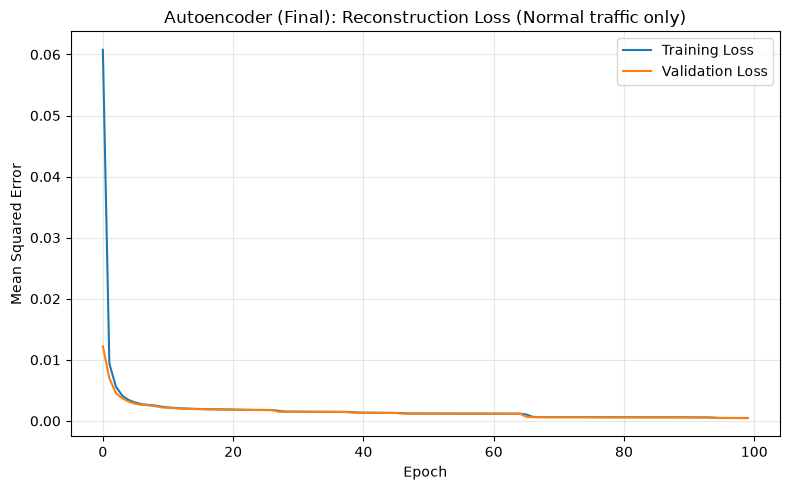

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Autoencoder (Final): Reconstruction Loss (Normal traffic only)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../figures/autoencoder_loss.png", dpi=300, bbox_inches="tight")
plt.show()


Reconstruction error distribution (final model)

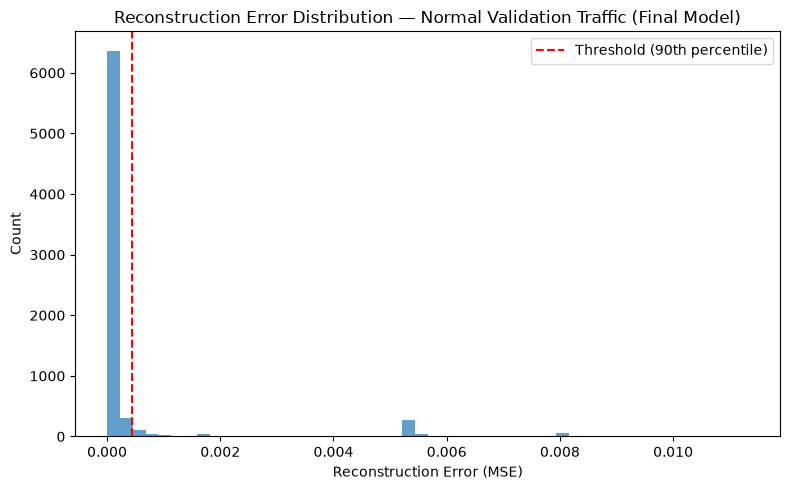

In [13]:
val_normal_errors = reconstruction_error(autoencoder, X_val_normal)

plt.figure(figsize=(8, 5))
plt.hist(val_normal_errors, bins=50, alpha=0.7)
plt.axvline(threshold, color="red", linestyle="--", label=f"Threshold ({THRESHOLD_PERCENTILE}th percentile)")
plt.title("Reconstruction Error Distribution — Normal Validation Traffic (Final Model)")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()

plt.savefig("../figures/autoencoder_threshold_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


Confusion matrix (final model)

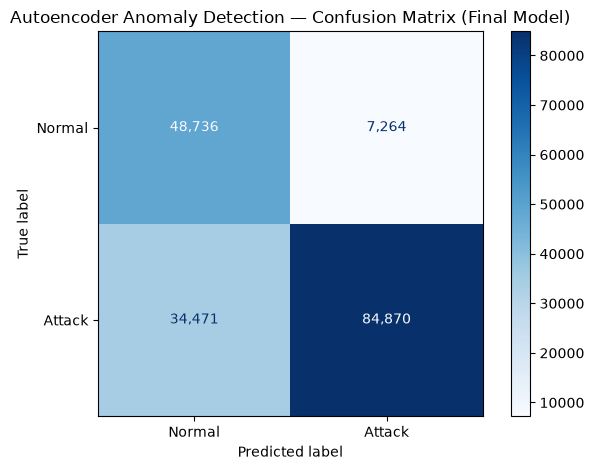

In [14]:
cm = confusion_matrix(y_test, predictions)

display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
display_cm.plot(values_format=",", cmap="Blues")
plt.title("Autoencoder Anomaly Detection — Confusion Matrix (Final Model)")
plt.tight_layout()

plt.savefig("../figures/autoencoder_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


ROC curve (final model)

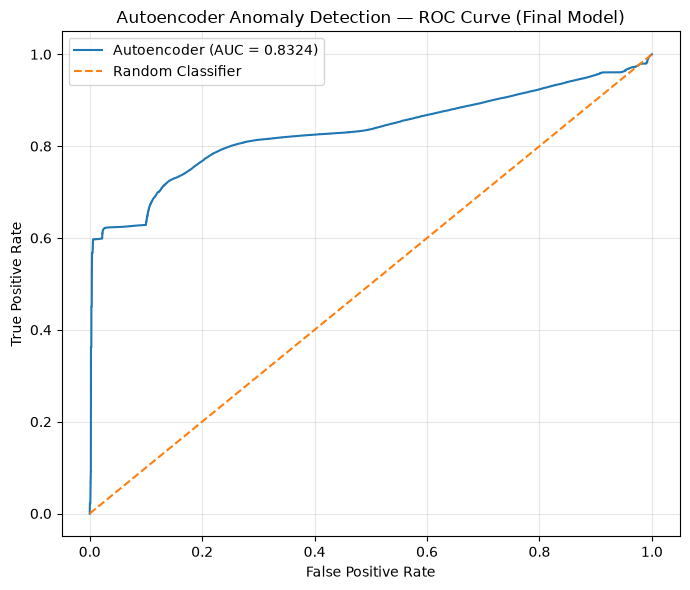

In [15]:
fpr, tpr, _ = roc_curve(y_test, test_errors)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Autoencoder (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("Autoencoder Anomaly Detection — ROC Curve (Final Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../figures/autoencoder_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


Classification report (final model)

In [16]:
report_df = pd.DataFrame(
    classification_report(
        y_test, predictions,
        target_names=["Normal", "Attack"],
        output_dict=True,
        zero_division=0
    )
).transpose()

report_df.to_csv("../results/autoencoder_classification_report.csv")
report_df


,precision,recall,f1-score,support
Normal,0.585720,0.870286,0.700195,56000.000000
Attack,0.921158,0.711155,0.802648,119341.000000
accuracy,0.761978,0.761978,0.761978,0.761978
macro avg,0.753439,0.790721,0.751421,175341.000000
weighted avg,0.814027,0.761978,0.769927,175341.000000


## Compare against the supervised DNN

Loads the binary experiment results (from `Binary_Baseline.ipynb` / `optimization.ipynb`) to compare the unsupervised autoencoder against the best supervised model on the same test set.

In [17]:
autoencoder_result = {
    "Experiment": "Autoencoder (unsupervised)",
    "Test Accuracy": accuracy,
    "Test Precision": precision,
    "Test Recall": recall,
    "Test F1": f1,
    "Test ROC-AUC": auc,
    "Training Time Seconds": training_time
}

comparison_rows = [autoencoder_result]

try:
    supervised_df = pd.read_csv("../results/binary_optimization_results.csv")
    best_supervised = supervised_df.sort_values("Test F1", ascending=False).iloc[0]
    comparison_rows.append({
        "Experiment": f"Best supervised DNN ({best_supervised['Experiment']})",
        "Test Accuracy": best_supervised["Test Accuracy"],
        "Test Precision": best_supervised["Test Precision"],
        "Test Recall": best_supervised["Test Recall"],
        "Test F1": best_supervised["Test F1"],
        "Test ROC-AUC": best_supervised["Test ROC-AUC"],
        "Training Time Seconds": best_supervised["Training Time Seconds"]
    })
except FileNotFoundError:
    print("Run optimization.ipynb first to include the supervised comparison.")

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("../results/autoencoder_vs_supervised_comparison.csv", index=False)
comparison_df


,Experiment,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Training Time Seconds
0,Autoencoder (unsupervised),0.761978,0.921158,0.711155,0.802648,0.832423,18.959822
1,Best supervised DNN (E3_Width_256-128),0.895381,0.987132,0.857467,0.917742,0.984198,14.688454


Save the autoencoder model

In [18]:
autoencoder.save("../models/autoencoder.keras")

pd.DataFrame([{
    "Threshold Percentile": THRESHOLD_PERCENTILE,
    "Threshold Value": threshold,
    "Encoding Dimension": encoding_dim,
    "Epochs Run": len(history.history["loss"]),
    "Training Time Seconds": training_time
}]).to_csv("../results/autoencoder_summary.csv", index=False)

print("Autoencoder model and summary saved successfully.")


Autoencoder model and summary saved successfully.
